## FoodCNN: Image Preprocessing and Model 

#### Imports 

In [1]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader , random_split
from torchvision import transforms, models
from PIL import Image

#### Dataset

In [3]:
# Base path 
BASE_PATH = "datasets/food-101"

In [4]:
# loading classes
def load_classes(base_path):
    with open(os.path.join(base_path, "meta", "labels.txt")) as f:
        classes = f.read().splitlines()
    class_to_idx = {cls: i for i, cls in enumerate(classes)}
    return classes, class_to_idx

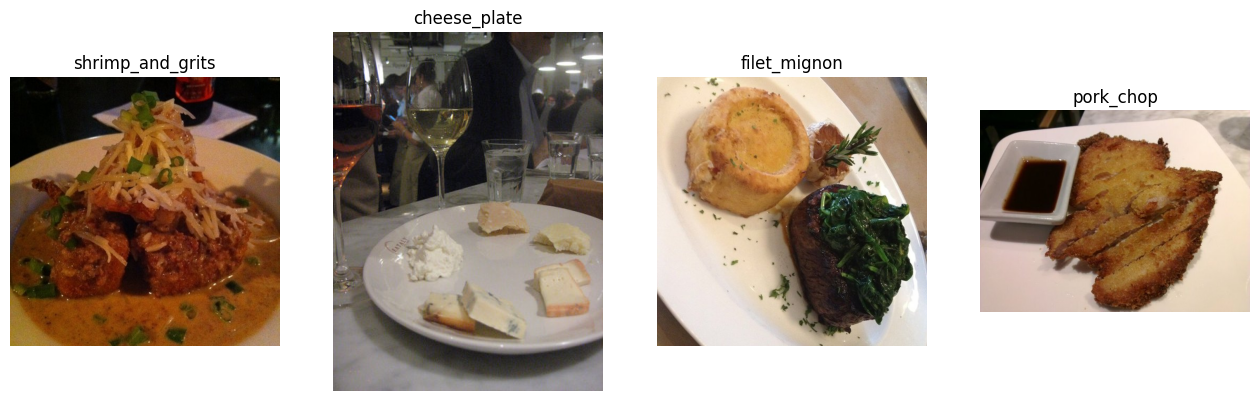

In [5]:
# images path
images_path = f"{BASE_PATH}/images"

plt.figure(figsize= (16 , 16))
# preview of 4 raw images 
for i , label in enumerate(random.choices(os.listdir(images_path ), k = 4) , 1):
    random_image = random.choice(os.listdir(f"{images_path}/{label}"))
    img = np.array(Image.open(f"{images_path}/{label}/{random_image}"))
    plt.subplot(1 , 4 , i)
    plt.title(label)
    plt.imshow(img)
    plt.axis("off")
plt.show()

In [6]:
# creating custom dataset compiatable with pytorch 
class Food101Dataset(Dataset):
    def __init__(self, base_path, split_file, transform=None):
        self.base_path = base_path
        self.image_path = os.path.join(base_path, "images")
        self.transform = transform

        with open(os.path.join(base_path, "meta", split_file)) as f:
            lines = f.read().splitlines()

        self.image_paths = [os.path.join(self.image_path, line + ".jpg") for line in lines]
        self.labels = [line.split('/')[0] for line in lines]

        self.classes = sorted(list(set(self.labels)))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.labels = [self.class_to_idx[label] for label in self.labels]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
# image transformation

# Training transform: augmentation + normalization

# Sequence of transformation  
#  RandomResizedCrop: randomly crops and resizes to 224x224 (simulates different zoom/framing)
#  RandomHorizontalFlip: randomly mirrors the image horizontally
#  ColorJitter: randomly varies brightness, contrast, saturation, hue
#  Normalize: scales pixel values using ImageNet mean & std so the
#   distribution matches what ResNet-50 was pretrained on
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),          
    transforms.RandomHorizontalFlip(),           # augmentation: random horizontal flip
    transforms.ColorJitter(
        brightness=0.2,                          # [0.8,1.2] slightly darker and slightly brighter
        contrast=0.2,                            # [0.8,1.2]  
        saturation=0.2,                          # [0.8,1.2]
        hue=0.1                                  # [−0.1,+0.1]
    ),                                           # augmentation: color jitter
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],              # ImageNet mean (R, G, B)
        std=[0.229, 0.224, 0.225]               # ImageNet std  (R, G, B)
    )
])

# Validation / test transform: deterministic resize + normalization only
# No augmentation here — we want a consistent, reproducible evaluation
val_transform = transforms.Compose([
    transforms.Resize(256),                      # resize shorter side to 256
    transforms.CenterCrop(224),                  # center-crop to 224x224
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print('Train transform (with augmentation):')
print(train_transform)
print()
print('Val/Test transform (deterministic):')
print(val_transform)


In [8]:
# split data
# load train dataset with augmentation transform
train_dataset_full = Food101Dataset(BASE_PATH, 'train.txt', train_transform)

# validation split — use val_transform (no augmentation) for the val portion
train_size = int(0.8 * len(train_dataset_full))
val_size   = len(train_dataset_full) - train_size

train_dataset, val_dataset_raw = random_split(
    train_dataset_full,
    [train_size, val_size]
)

# Re-wrap the validation split with val_transform so augmentation is NOT applied
class TransformSubset(torch.utils.data.Dataset):
    """Wraps a random_split Subset and applies a different transform."""
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img_path = self.subset.dataset.image_paths[self.subset.indices[idx]]
        label    = self.subset.dataset.labels[self.subset.indices[idx]]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

val_dataset  = TransformSubset(val_dataset_raw, val_transform)

# test dataset — also uses val_transform (no augmentation)
test_dataset = Food101Dataset(BASE_PATH, 'test.txt', val_transform)

print('Train size:     ', len(train_dataset))
print('Validation size:', len(val_dataset))
print('Test size:      ', len(test_dataset))


Train size:  60600
Validation size:  15150
Test size :  25250


In [9]:
# dataset loader 
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True , num_workers=2)
val_loader = DataLoader(val_dataset , batch_size=32 , num_workers = 2)
test_loader = DataLoader(test_dataset, batch_size=32 , num_workers=2)

In [10]:
# Stage 3: CNN backbone (ResNet-50)
# ResNet-50 pretrained on ImageNet. Global average pooling outputs a
# 2048-dimensional feature vector encoding textures, colors, shapes.
from torchvision.models import resnet50, ResNet50_Weights

backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

# Stage 4: Visual embedding projection head (2048 -> 512)
# Linear projection compresses 2048-d CNN output to 512-d visual embed v.
# Dropout(0.3) added for regularisation before the classifier.
backbone.fc = nn.Sequential(
    nn.Linear(2048, 512),   # visual embed v in R^512
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 101)     # 101-class Food-101 classifier
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(backbone.parameters(), lr=1e-3)

# Cosine annealing LR scheduler - smoothly decays LR over training
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print(backbone)


c:\Users\LEGION\Documents\AI&ML\FoodIntel-AI\food_venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\LEGION\Documents\AI&ML\FoodIntel-AI\food_venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
backbone = backbone.to(device)


In [ ]:
import os

os.makedirs("checkpoints", exist_ok=True)

NUM_EPOCHS   = 10
best_val_acc = 0.0
history      = {"train_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    # Training
    backbone.train()
    total_loss  = 0.0
    num_batches = len(train_loader)

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = backbone(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if (batch_idx + 1) % 100 == 0:
            print(f"  Epoch [{epoch+1}/{NUM_EPOCHS}]"
                  f"  Batch [{batch_idx+1}/{num_batches}]"
                  f"  Batch Loss: {loss.item():.4f}")

    scheduler.step()  # update LR after each epoch

    # Validation
    backbone.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = backbone(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    val_acc    = correct / total
    avg_loss   = total_loss / num_batches
    current_lr = scheduler.get_last_lr()[0]

    history["train_loss"].append(avg_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]"
          f"  Avg Loss: {avg_loss:.4f}"
          f"  Val Acc: {val_acc:.4f}"
          f"  LR: {current_lr:.6f}")

    # Save best checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch":           epoch + 1,
            "model_state":     backbone.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_acc":         val_acc,
        }, "checkpoints/best_model.pth")
        print(f"  -> Saved best model (val_acc={val_acc:.4f})")

print(f"Training complete. Best val acc: {best_val_acc:.4f}")


In [ ]:
# Load best checkpoint for final evaluation
checkpoint = torch.load("checkpoints/best_model.pth", map_location=device)
backbone.load_state_dict(checkpoint["model_state"])
print(f"Loaded best model from epoch {checkpoint['epoch']}"
      f" (val_acc={checkpoint['val_acc']:.4f})")

# Test evaluation
backbone.eval()
correct = 0
total   = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = backbone(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

test_acc = correct / total
print(f"Test Accuracy: {test_acc:.4f}")

# Training curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], marker="o")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

axes[1].plot(history["val_acc"], marker="o", color="orange")
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True)

plt.tight_layout()
plt.savefig("checkpoints/training_curve.png", dpi=150)
plt.show()
print("Training curve saved to checkpoints/training_curve.png")
